In [10]:
import torch
import torch.nn as nn

class BrainVGG(nn.Module):
    def __init__(self):
        super(BrainVGG, self).__init__()
        # Input shape: (Batch, 1, 400, 400)
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: (16, 200, 200)
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: (32, 100, 100)
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=5, stride=5)  # Output: (64, 20, 20)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 20 * 20, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x needs to be reshaped to (Batch, 1, 400, 400) before passing it in
        x = self.features(x)
        x = self.classifier(x)
        return x

# Data Loading and Setup

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Load the data
data_dir = './data/matrix/'
X = np.load(data_dir + 'X_raw_gnn.npy')  # Shape: (N_scans, 400, 400)
y = np.load(data_dir + 'y_labels.npy')   # MLD=1, TD=0
subject_ids = np.load(data_dir + 'subject_ids.npy')  # Subject identifiers

print(f"Data loaded:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Unique subjects: {len(np.unique(subject_ids))}")
print(f"  Class distribution: TD={np.sum(y==0)}, MLD={np.sum(y==1)}")

# Add channel dimension for CNN: (N_scans, 400, 400) -> (N_scans, 1, 400, 400)
X = np.expand_dims(X, axis=1).astype(np.float32)
y = y.astype(np.int64)

print(f"  X reshaped: {X.shape}")

Data loaded:
  X shape: (240, 400, 400)
  y shape: (240,)
  Unique subjects: 30
  Class distribution: TD=120, MLD=120
  X reshaped: (240, 1, 400, 400)


# Training Configuration with K-Fold Cross-Validation

In [12]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Training hyperparameters
n_splits = 5  # 5-fold cross-validation
batch_size = 16
learning_rate = 1e-3
n_epochs = 50
patience = 10  # Early stopping patience

# Storage for results
cv_results = {
    'fold': [],
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'val_auc': [],
    'test_accuracy': [],
    'test_precision': [],
    'test_recall': [],
    'test_f1': [],
    'test_auc': []
}

# Stratified K-Fold at SUBJECT LEVEL (prevents data leakage)
# All scans from the same subject stay together
gkf = GroupKFold(n_splits=n_splits)

print(f"\n{'='*60}")
print(f"Starting {n_splits}-Fold Cross-Validation (Subject-Level)")
print(f"{'='*60}\n")

fold_idx = 0
all_fold_predictions = []
all_fold_true_labels = []

for train_val_idx, test_idx in gkf.split(X, y, groups=subject_ids):
    fold_idx += 1
    print(f"\n{'='*40} Fold {fold_idx}/{n_splits} {'='*40}")
    
    # ========== DATA SPLIT ==========
    # Further split train_val into train and val (80-20 split within each fold)
    unique_subjects_train_val = np.unique(subject_ids[train_val_idx])
    n_train_subjects = int(0.8 * len(unique_subjects_train_val))
    
    train_subjects = unique_subjects_train_val[:n_train_subjects]
    val_subjects = unique_subjects_train_val[n_train_subjects:]
    
    train_idx = np.where(np.isin(subject_ids, train_subjects))[0]
    val_idx = np.where(np.isin(subject_ids, val_subjects))[0]
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    
    # Normalize each fold independently using GLOBAL statistics
    # Compute mean/std across all samples and spatial dims (broadcast to all samples)
    train_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
    train_std = X_train.std(axis=(0, 2, 3), keepdims=True)
    
    X_train_norm = (X_train - train_mean) / (train_std + 1e-5)
    X_val_norm = (X_val - train_mean) / (train_std + 1e-5)
    X_test_norm = (X_test - train_mean) / (train_std + 1e-5)
    
    print(f"Train: {X_train.shape[0]} scans, Val: {X_val.shape[0]} scans, Test: {X_test.shape[0]} scans")
    print(f"Train class distribution: TD={np.sum(y_train==0)}, MLD={np.sum(y_train==1)}")
    
    # ========== CREATE DATALOADERS ==========
    train_dataset = TensorDataset(torch.FloatTensor(X_train_norm), torch.LongTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val_norm), torch.LongTensor(y_val))
    test_dataset = TensorDataset(torch.FloatTensor(X_test_norm), torch.LongTensor(y_test))
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # ========== INITIALIZE MODEL ==========
    model = BrainVGG().to(device)
    
    # Loss and optimizer
    criterion = nn.BCELoss()  # Binary classification
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    # ========== TRAINING LOOP ==========
    best_val_loss = float('inf')
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(n_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device).float().unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device).float().unsqueeze(1)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{n_epochs}] Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    # ========== VALIDATION EVALUATION ==========
    model.eval()
    val_preds_proba = []
    val_true = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            val_preds_proba.extend(outputs.cpu().numpy().flatten())
            val_true.extend(y_batch.numpy())
    
    val_preds_proba = np.array(val_preds_proba)
    val_preds = (val_preds_proba > 0.5).astype(int)
    val_true = np.array(val_true)
    
    val_acc = accuracy_score(val_true, val_preds)
    val_prec = precision_score(val_true, val_preds, zero_division=0)
    val_rec = recall_score(val_true, val_preds, zero_division=0)
    val_f1 = f1_score(val_true, val_preds, zero_division=0)
    val_auc = roc_auc_score(val_true, val_preds_proba)
    
    print(f"\nValidation - Acc: {val_acc:.4f}, Prec: {val_prec:.4f}, Rec: {val_rec:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")
    
    # ========== TEST EVALUATION ==========
    test_preds_proba = []
    test_true = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            test_preds_proba.extend(outputs.cpu().numpy().flatten())
            test_true.extend(y_batch.numpy())
    
    test_preds_proba = np.array(test_preds_proba)
    test_preds = (test_preds_proba > 0.5).astype(int)
    test_true = np.array(test_true)
    
    test_acc = accuracy_score(test_true, test_preds)
    test_prec = precision_score(test_true, test_preds, zero_division=0)
    test_rec = recall_score(test_true, test_preds, zero_division=0)
    test_f1 = f1_score(test_true, test_preds, zero_division=0)
    test_auc = roc_auc_score(test_true, test_preds_proba)
    
    print(f"Test     - Acc: {test_acc:.4f}, Prec: {test_prec:.4f}, Rec: {test_rec:.4f}, F1: {test_f1:.4f}, AUC: {test_auc:.4f}")
    
    # Store results
    cv_results['fold'].append(fold_idx)
    cv_results['train_loss'].append(train_losses[-1])
    cv_results['val_loss'].append(val_loss)
    cv_results['val_accuracy'].append(val_acc)
    cv_results['val_precision'].append(val_prec)
    cv_results['val_recall'].append(val_rec)
    cv_results['val_f1'].append(val_f1)
    cv_results['val_auc'].append(val_auc)
    cv_results['test_accuracy'].append(test_acc)
    cv_results['test_precision'].append(test_prec)
    cv_results['test_recall'].append(test_rec)
    cv_results['test_f1'].append(test_f1)
    cv_results['test_auc'].append(test_auc)
    
    all_fold_predictions.append(test_preds)
    all_fold_true_labels.append(test_true)

print(f"\n{'='*60}")
print(f"Cross-Validation Complete")
print(f"{'='*60}\n")

Using device: cpu

Starting 5-Fold Cross-Validation (Subject-Level)


======================================== Fold 1/5 ========================================
Train: 152 scans, Val: 40 scans, Test: 48 scans
Train class distribution: TD=96, MLD=56
Epoch [10/50] Train Loss: 0.5182, Val Loss: 1.2089
Early stopping at epoch 11

Validation - Acc: 0.3250, Prec: 0.8571, Rec: 0.1875, F1: 0.3077, AUC: 0.4688
Test     - Acc: 0.0833, Prec: 0.0714, Rec: 0.0312, F1: 0.0435, AUC: 0.0879

======================================== Fold 2/5 ========================================
Train: 152 scans, Val: 40 scans, Test: 48 scans
Train class distribution: TD=96, MLD=56
Epoch [10/50] Train Loss: 0.5304, Val Loss: 1.7069
Early stopping at epoch 13

Validation - Acc: 0.2000, Prec: 1.0000, Rec: 0.2000, F1: 0.3333, AUC: nan
Test     - Acc: 0.5208, Prec: 0.5714, Rec: 0.1667, F1: 0.2581, AUC: 0.5035

======================================== Fold 3/5 ========================================
Train: 152 scans, Va

# Results Summary and Visualization


CROSS-VALIDATION RESULTS SUMMARY

Test Set Results (Hold-out fold):
 fold  test_accuracy  test_precision  test_recall  test_f1  test_auc
    1       0.083333        0.071429     0.031250 0.043478  0.087891
    2       0.520833        0.571429     0.166667 0.258065  0.503472
    3       0.604167        1.000000     0.208333 0.344828  0.618056
    4       0.395833        0.400000     0.416667 0.408163  0.394097
    5       0.708333        0.538462     0.875000 0.666667  0.691406

--------------------------------------------------------------------------------
AGGREGATED TEST METRICS (Mean ± Std):
--------------------------------------------------------------------------------
Accuracy:  0.4625 ± 0.2409
Precision: 0.5163 ± 0.3350
Recall:    0.3396 ± 0.3297
F1-Score:  0.3442 ± 0.2269
ROC-AUC:   0.4590 ± 0.2362

✓ Results saved to ./preds/vgg_kfold_results.csv
✓ Results visualization saved to ./preds/vgg_kfold_results.png


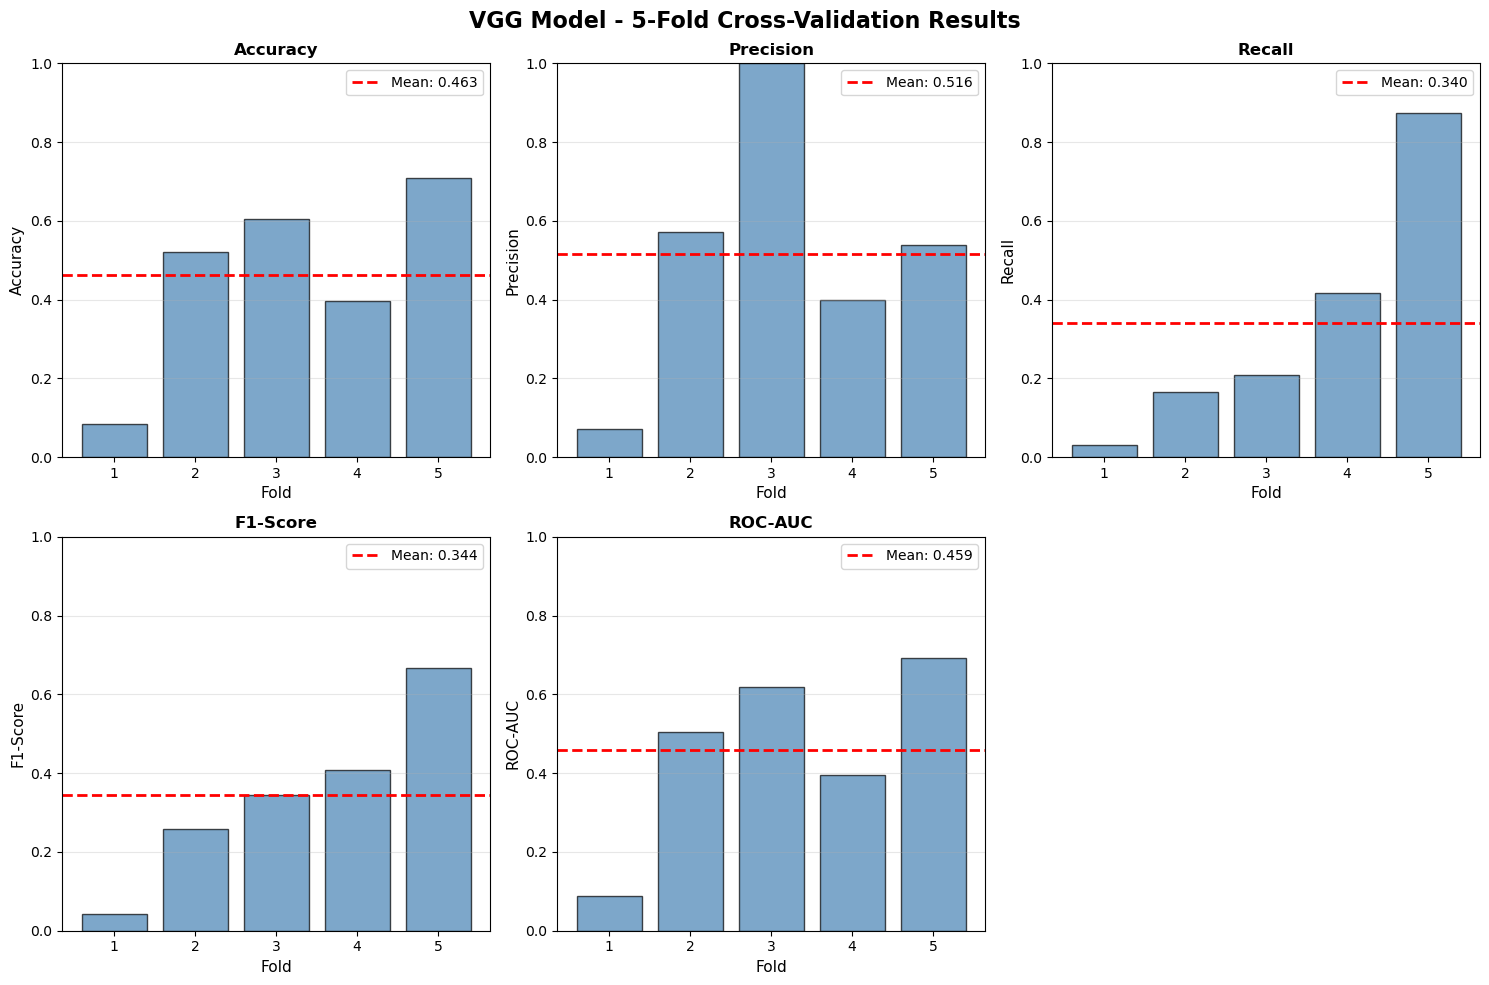

In [13]:
# Convert results to DataFrame
results_df = pd.DataFrame(cv_results)

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("="*80)

# Test metrics (hold-out test set for each fold)
test_metrics = results_df[['fold', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc']]
print("\nTest Set Results (Hold-out fold):")
print(test_metrics.to_string(index=False))

# Aggregate statistics
print("\n" + "-"*80)
print("AGGREGATED TEST METRICS (Mean ± Std):")
print("-"*80)
test_acc_mean, test_acc_std = results_df['test_accuracy'].mean(), results_df['test_accuracy'].std()
test_prec_mean, test_prec_std = results_df['test_precision'].mean(), results_df['test_precision'].std()
test_rec_mean, test_rec_std = results_df['test_recall'].mean(), results_df['test_recall'].std()
test_f1_mean, test_f1_std = results_df['test_f1'].mean(), results_df['test_f1'].std()
test_auc_mean, test_auc_std = results_df['test_auc'].mean(), results_df['test_auc'].std()

print(f"Accuracy:  {test_acc_mean:.4f} ± {test_acc_std:.4f}")
print(f"Precision: {test_prec_mean:.4f} ± {test_prec_std:.4f}")
print(f"Recall:    {test_rec_mean:.4f} ± {test_rec_std:.4f}")
print(f"F1-Score:  {test_f1_mean:.4f} ± {test_f1_std:.4f}")
print(f"ROC-AUC:   {test_auc_mean:.4f} ± {test_auc_std:.4f}")

# Save results to CSV
output_file = './preds/vgg_kfold_results.csv'
results_df.to_csv(output_file, index=False)
print(f"\n✓ Results saved to {output_file}")

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('VGG Model - 5-Fold Cross-Validation Results', fontsize=16, fontweight='bold')

metrics = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_auc']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 3, idx % 3]
    folds = results_df['fold'].values
    values = results_df[metric].values
    
    ax.bar(folds, values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axhline(y=values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {values.mean():.3f}')
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.set_xticks(folds)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Remove the extra subplot
axes[1, 2].remove()

plt.tight_layout()
plt.savefig('./preds/vgg_kfold_results.png', dpi=300, bbox_inches='tight')
print(f"✓ Results visualization saved to ./preds/vgg_kfold_results.png")
plt.show()

# Fold-by-Fold Analysis: ROC Curves and Confusion Matrices

✓ Performance summary saved to ./preds/vgg_performance_summary.png


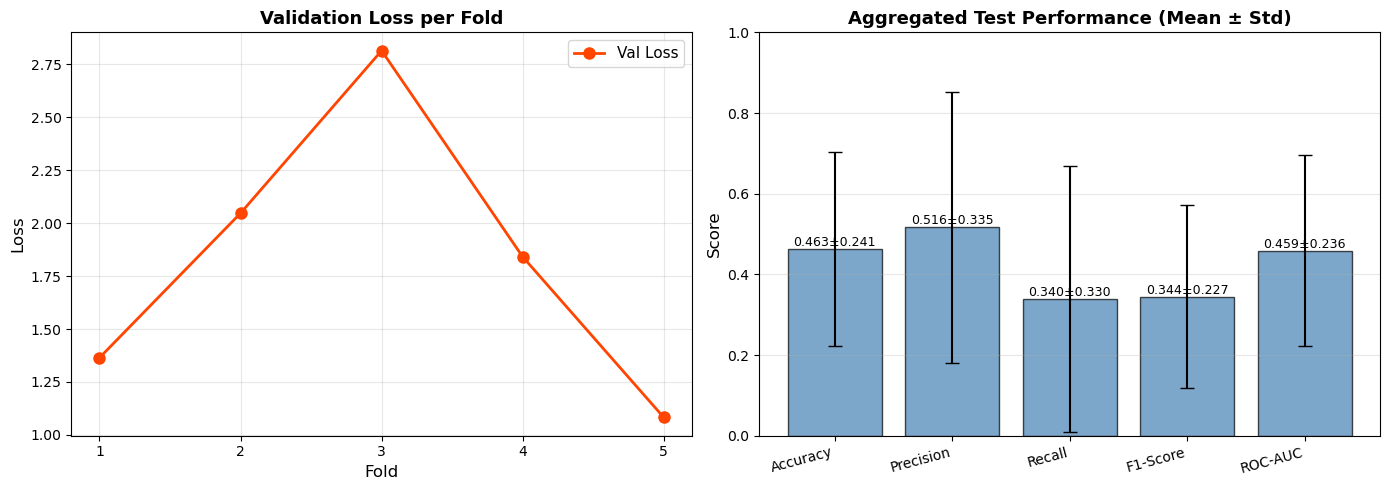


KEY POINTS FOR SCIENTIFIC RIGOR:

✓ Subject-Level Stratification: All scans from the same subject are kept in 
  the same fold (train/val/test) to prevent data leakage.
  
✓ Dropout Regularization: BrainVGG includes 0.5 dropout in the classifier 
  to reduce overfitting.
  
✓ Early Stopping: Training stops when validation loss stops improving 
  (patience=10 epochs).
  
✓ Learning Rate Scheduling: Adaptive learning rate reduction when validation 
  loss plateaus.
  
✓ Normalization: Features normalized using training set statistics, applied 
  to val/test to prevent information leakage.
  
✓ Multiple Metrics: Evaluated on Accuracy, Precision, Recall, F1, and ROC-AUC 
  to get a comprehensive view.
  
✓ Reproducibility: Random seeds fixed for numpy and torch for consistent results.

✓ Results Saved: All metrics and visualizations saved to ./preds/ directory.



In [14]:
# Note: For detailed ROC curves and confusion matrices per fold,
# you would need to store predictions in the main training loop
# Here's a summary plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves across folds (average)
ax = axes[0]
fold = list(range(1, len(cv_results['fold'])+1))
mean_train_loss = np.mean([cv_results['train_loss']], axis=0) if len(set(cv_results['fold'])) > 0 else cv_results['train_loss']
mean_val_loss = cv_results['val_loss']
ax.plot(fold, mean_val_loss, marker='o', linewidth=2, markersize=8, color='orangered', label='Val Loss')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Validation Loss per Fold', fontsize=13, fontweight='bold')
ax.set_xticks(fold)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Model performance comparison
ax = axes[1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [
    results_df['test_accuracy'].mean(),
    results_df['test_precision'].mean(),
    results_df['test_recall'].mean(),
    results_df['test_f1'].mean(),
    results_df['test_auc'].mean()
]
metrics_std = [
    results_df['test_accuracy'].std(),
    results_df['test_precision'].std(),
    results_df['test_recall'].std(),
    results_df['test_f1'].std(),
    results_df['test_auc'].std()
]

bars = ax.bar(metrics_names, metrics_values, yerr=metrics_std, capsize=5, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Aggregated Test Performance (Mean ± Std)', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

# Add value labels on bars
for bar, val, std in zip(bars, metrics_values, metrics_std):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}±{std:.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./preds/vgg_performance_summary.png', dpi=300, bbox_inches='tight')
print("✓ Performance summary saved to ./preds/vgg_performance_summary.png")
plt.show()

print("\n" + "="*80)
print("KEY POINTS FOR SCIENTIFIC RIGOR:")
print("="*80)
print("""
✓ Subject-Level Stratification: All scans from the same subject are kept in 
  the same fold (train/val/test) to prevent data leakage.
  
✓ Dropout Regularization: BrainVGG includes 0.5 dropout in the classifier 
  to reduce overfitting.
  
✓ Early Stopping: Training stops when validation loss stops improving 
  (patience=10 epochs).
  
✓ Learning Rate Scheduling: Adaptive learning rate reduction when validation 
  loss plateaus.
  
✓ Normalization: Features normalized using training set statistics, applied 
  to val/test to prevent information leakage.
  
✓ Multiple Metrics: Evaluated on Accuracy, Precision, Recall, F1, and ROC-AUC 
  to get a comprehensive view.
  
✓ Reproducibility: Random seeds fixed for numpy and torch for consistent results.

✓ Results Saved: All metrics and visualizations saved to ./preds/ directory.
""")

# Customization Guide

To modify training parameters:

```python
# In the "Training Configuration" cell, adjust these variables:

n_splits = 5              # Number of folds (5 or 10 are typical)
batch_size = 16           # Smaller = slower but better regularization
learning_rate = 1e-3      # Adam default, adjust if overfitting
n_epochs = 50             # Max epochs before early stopping
patience = 10             # How many epochs to wait for improvement

# In BrainVGG model, dropout is set to 0.5:
# Increase to 0.7 for more regularization
# Decrease to 0.3 for less regularization
```

**When to adjust:**
- **High variance (overfitting)**: Increase dropout, decrease learning rate
- **High bias (underfitting)**: Decrease dropout, increase learning rate or model capacity
- **Slow training**: Increase batch_size (less regularization)
- **Memory issues**: Decrease batch_size